# HW4: Обучение с подкреплением с использованием модели мира

1. Q-learning vs Q-learning + Dyna на **Taxi-v3** (дискретные S, A)
2. PPO vs PPO + World Model на **CartPole-v1** (непрерывные S, дискретные A)
3. PPO vs PPO + World Model на **Pendulum-v1** (непрерывные S, A)

Для каждого задания: 2 сида на алгоритм, графики сходимости, гифка поведения, выводы по гиперпараметрам.

In [1]:
!pip install -q gymnasium
!pip install -q imageio

In [2]:
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions.categorical import Categorical
from torch.distributions.normal import Normal
from collections import defaultdict
import gymnasium as gym
import matplotlib.pyplot as plt
import imageio
from IPython.display import Image, display, clear_output

%matplotlib inline
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
def record_gif(env, policy, path, duration=500, fps=30):
    frames = []
    state, _ = env.reset()
    for _ in range(duration):
        action = policy(state)
        frames.append(env.render())
        state, _, terminated, truncated, _ = env.step(action)
        if terminated or truncated:
            break
    env.close()
    imageio.mimsave(path, frames, fps=fps)
    return path

def smooth(y, k=20):
    if len(y) < 2:
        return y
    k = min(k, len(y))
    return np.convolve(y, np.ones(k)/k, mode='valid')

def plot_runs(runs, title, xlabel='steps'):
    plt.figure(figsize=(9, 4))
    for label, (xs, ys) in runs.items():
        ys_s = smooth(ys)
        xs_s = xs[len(xs) - len(ys_s):]
        plt.plot(xs_s, ys_s, label=label)
    plt.xlabel(xlabel)
    plt.ylabel('mean reward')
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

## Задание 1. Q-learning vs Q-learning + Dyna (Taxi-v3)

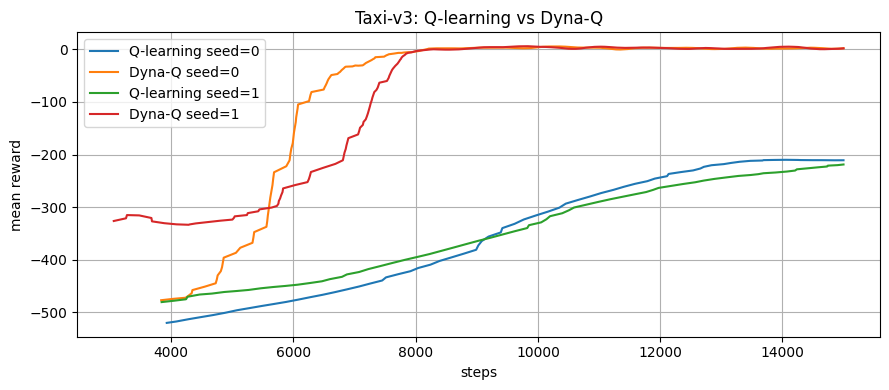

In [4]:
def train_q(env_name, seed, n_planning=0, alpha=0.3, gamma=0.99, eps=0.1, max_steps=15000):
    random.seed(seed)
    np.random.seed(seed)
    env = gym.make(env_name)
    env.reset(seed=seed)
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    model = defaultdict(dict)
    xs, ys = [], []
    ep_rewards = []
    step = 0
    while step < max_steps:
        s, _ = env.reset()
        done = False
        total = 0
        while not done and step < max_steps:
            a = env.action_space.sample() if random.random() < eps else int(np.argmax(Q[s]))
            s2, r, term, trunc, _ = env.step(a)
            done = term or trunc
            total += r
            Q[s][a] = (1 - alpha) * Q[s][a] + alpha * (r + gamma * np.max(Q[s2]) * (1 - done))
            model[s][a] = (r, s2, done)
            for _ in range(n_planning):
                ms = random.choice(list(model.keys()))
                ma = random.choice(list(model[ms].keys()))
                mr, ms2, md = model[ms][ma]
                Q[ms][ma] = (1 - alpha) * Q[ms][ma] + alpha * (mr + gamma * np.max(Q[ms2]) * (1 - md))
            s = s2
            step += 1
        ep_rewards.append(total)
        xs.append(step)
        ys.append(np.mean(ep_rewards[-30:]))
    env.close()
    return Q, xs, ys

task1_runs = {}
trained_Qs = {}
for seed in [0, 1]:
    Q, xs, ys = train_q('Taxi-v3', seed=seed, n_planning=0, max_steps=15000)
    task1_runs[f'Q-learning seed={seed}'] = (xs, ys)
    trained_Qs[f'Q_seed{seed}'] = Q
    Q, xs, ys = train_q('Taxi-v3', seed=seed, n_planning=50, max_steps=15000)
    task1_runs[f'Dyna-Q seed={seed}'] = (xs, ys)
    trained_Qs[f'Dyna_seed{seed}'] = Q

plot_runs(task1_runs, 'Taxi-v3: Q-learning vs Dyna-Q')

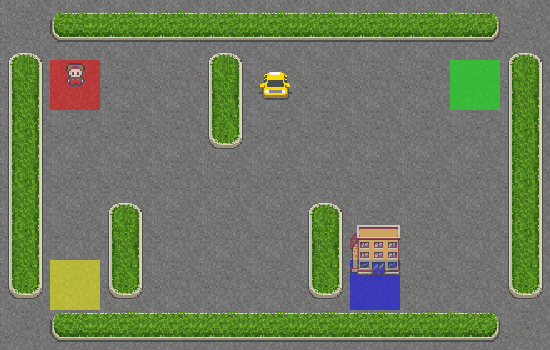

In [5]:
Q = trained_Qs['Dyna_seed0']
env = gym.make('Taxi-v3', render_mode='rgb_array')
policy = lambda s: int(np.argmax(Q[s]))
record_gif(env, policy, 'taxi.gif', duration=200, fps=5)
display(Image('taxi.gif'))

## PPO + World Model: общие компоненты

In [6]:
def make_env(env_id):
    def thunk():
        env = gym.make(env_id)
        env = gym.wrappers.RecordEpisodeStatistics(env)
        return env
    return thunk

def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    torch.nn.init.orthogonal_(layer.weight, std)
    torch.nn.init.constant_(layer.bias, bias_const)
    return layer

class WorldModel(nn.Module):
    def __init__(self, obs_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            layer_init(nn.Linear(obs_dim + action_dim, 128)),
            nn.SiLU(),
            layer_init(nn.Linear(128, 64)),
            nn.SiLU(),
        )
        self.reward_net = layer_init(nn.Linear(64, 1), std=0.01)
        self.next_obs_net = layer_init(nn.Linear(64, obs_dim), std=0.01)
        self.done_net = layer_init(nn.Linear(64, 1), std=0.01)

    def forward(self, obs, action):
        x = torch.cat([obs, action], dim=-1)
        h = self.net(x)
        return self.reward_net(h), self.next_obs_net(h), torch.sigmoid(self.done_net(h))

class Agent(nn.Module):
    def __init__(self, envs, continue_action=False):
        super().__init__()
        self.continue_action = continue_action
        obs_dim = int(np.prod(envs.single_observation_space.shape))
        self.critic = nn.Sequential(
            layer_init(nn.Linear(obs_dim, 64)), nn.Tanh(),
            layer_init(nn.Linear(64, 64)), nn.Tanh(),
            layer_init(nn.Linear(64, 1), std=1.0),
        )
        if continue_action:
            act_dim = int(np.prod(envs.single_action_space.shape))
            self.actor_mean = nn.Sequential(
                layer_init(nn.Linear(obs_dim, 64)), nn.Tanh(),
                layer_init(nn.Linear(64, 64)), nn.Tanh(),
                layer_init(nn.Linear(64, act_dim), std=0.01),
            )
            self.actor_logstd = nn.Parameter(torch.zeros(1, act_dim))
        else:
            self.actor = nn.Sequential(
                layer_init(nn.Linear(obs_dim, 64)), nn.Tanh(),
                layer_init(nn.Linear(64, 64)), nn.Tanh(),
                layer_init(nn.Linear(64, envs.single_action_space.n), std=0.01),
            )

    def get_value(self, x):
        return self.critic(x)

    def get_action_and_value(self, x, action=None):
        if self.continue_action:
            mean = self.actor_mean(x)
            logstd = self.actor_logstd.expand_as(mean)
            probs = Normal(mean, torch.exp(logstd))
            if action is None:
                action = probs.sample()
            return action, probs.log_prob(action).sum(1), probs.entropy().sum(1), self.critic(x)
        logits = self.actor(x)
        probs = Categorical(logits=logits)
        if action is None:
            action = probs.sample()
        return action, probs.log_prob(action), probs.entropy(), self.critic(x)

In [7]:
def train_ppo(env_id, seed, total_timesteps, continuous, use_wm,
              num_envs=8, num_steps=128, lr=2.5e-4, gamma=0.99, gae_lambda=0.95,
              num_minibatches=4, update_epochs=4, clip_coef=0.2, ent_coef=0.01,
              vf_coef=0.5, max_grad_norm=0.5, anneal_lr=True,
              wm_lr=2.5e-3, wm_updates=8, wm_batch=128,
              imagination_steps=15, imagination_batch=40, img_epochs=2, img_iters=2,
              warmup=5):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    batch_size = num_envs * num_steps
    minibatch_size = batch_size // num_minibatches
    num_iterations = total_timesteps // batch_size
    envs = gym.vector.SyncVectorEnv([make_env(env_id) for _ in range(num_envs)])
    obs_shape = envs.single_observation_space.shape
    act_shape = envs.single_action_space.shape
    obs_dim = int(np.prod(obs_shape))
    act_dim = int(np.prod(act_shape)) if continuous else 1
    agent = Agent(envs, continue_action=continuous).to(device)
    optimizer = optim.Adam(agent.parameters(), lr=lr, eps=1e-5)
    if use_wm:
        world_model = WorldModel(obs_dim, act_dim).to(device)
        wm_opt = optim.Adam(world_model.parameters(), lr=wm_lr)
    obs = torch.zeros((num_steps, num_envs) + obs_shape).to(device)
    actions = torch.zeros((num_steps, num_envs) + act_shape).to(device)
    logprobs = torch.zeros((num_steps, num_envs)).to(device)
    rewards = torch.zeros((num_steps, num_envs)).to(device)
    dones = torch.zeros((num_steps, num_envs)).to(device)
    values = torch.zeros((num_steps, num_envs)).to(device)
    next_obs, _ = envs.reset(seed=seed)
    next_obs = torch.Tensor(next_obs).to(device)
    next_done = torch.zeros(num_envs).to(device)
    train_rewards = []
    xs, ys = [], []
    global_step = 0
    world_obs = world_actions = world_rewards = world_next_obs = world_dones = None
    for iteration in range(1, num_iterations + 1):
        if anneal_lr:
            frac = 1.0 - (iteration - 1.0) / num_iterations
            optimizer.param_groups[0]['lr'] = frac * lr
        for step in range(num_steps):
            global_step += num_envs
            obs[step] = next_obs
            dones[step] = next_done
            with torch.no_grad():
                action, logprob, _, value = agent.get_action_and_value(next_obs)
                values[step] = value.flatten()
            actions[step] = action
            logprobs[step] = logprob
            act_np = action.cpu().numpy()
            if continuous:
                act_np = np.clip(act_np, envs.single_action_space.low, envs.single_action_space.high)
            next_obs_np, reward, term, trunc, infos = envs.step(act_np)
            np_done = np.logical_or(term, trunc)
            rewards[step] = torch.tensor(reward).to(device).view(-1)
            next_obs = torch.Tensor(next_obs_np).to(device)
            next_done = torch.Tensor(np_done).to(device)
            if use_wm:
                a_store = action if continuous else action.unsqueeze(-1).float()
                tup = (next_obs.unsqueeze(0), a_store.unsqueeze(0),
                       torch.tensor(reward).to(device).unsqueeze(0),
                       next_obs.unsqueeze(0), next_done.unsqueeze(0))
                if world_obs is None:
                    world_obs, world_actions, world_rewards, world_next_obs, world_dones = tup
                else:
                    world_obs = torch.cat([world_obs, tup[0]])
                    world_actions = torch.cat([world_actions, tup[1]])
                    world_rewards = torch.cat([world_rewards, tup[2]])
                    world_next_obs = torch.cat([world_next_obs, tup[3]])
                    world_dones = torch.cat([world_dones, tup[4]])
            if 'final_info' in infos:
                for fi in infos['final_info']:
                    if fi is not None and 'episode' in fi:
                        train_rewards.append(float(np.asarray(fi['episode']['r']).item()))
            elif 'episode' in infos:
                mask = np_done
                if mask.sum() > 0:
                    train_rewards.append(float((infos['episode']['r'] * mask).sum() / mask.sum()))
        if use_wm and iteration > 1:
            for _ in range(wm_updates):
                idx = np.random.randint(0, world_obs.shape[0], wm_batch // num_envs)
                ob = world_obs[idx].reshape(-1, obs_dim).to(device)
                ac = world_actions[idx].reshape(-1, act_dim).to(device)
                rw = world_rewards[idx].reshape(-1, 1).float().to(device)
                no = world_next_obs[idx].reshape(-1, obs_dim).to(device)
                dn = world_dones[idx].reshape(-1, 1).float().to(device)
                pr, pno, pd = world_model(ob, ac)
                loss_wm = nn.MSELoss()(pr, rw) + nn.MSELoss()(pno, no) + nn.BCELoss()(pd, dn)
                wm_opt.zero_grad()
                loss_wm.backward()
                wm_opt.step()
        with torch.no_grad():
            next_value = agent.get_value(next_obs).reshape(1, -1)
            advantages = torch.zeros_like(rewards).to(device)
            lastgaelam = 0
            for t in reversed(range(num_steps)):
                if t == num_steps - 1:
                    nextnonterminal = 1.0 - next_done
                    nextvalues = next_value
                else:
                    nextnonterminal = 1.0 - dones[t + 1]
                    nextvalues = values[t + 1]
                delta = rewards[t] + gamma * nextvalues * nextnonterminal - values[t]
                advantages[t] = lastgaelam = delta + gamma * gae_lambda * nextnonterminal * lastgaelam
            returns = advantages + values
        b_obs = obs.reshape((-1,) + obs_shape)
        b_logprobs = logprobs.reshape(-1)
        b_actions = actions.reshape((-1,) + act_shape)
        b_advantages = advantages.reshape(-1)
        b_returns = returns.reshape(-1)
        b_values = values.reshape(-1)
        b_inds = np.arange(batch_size)
        for _ in range(update_epochs):
            np.random.shuffle(b_inds)
            for start in range(0, batch_size, minibatch_size):
                mb_inds = b_inds[start:start + minibatch_size]
                ma = b_actions[mb_inds] if continuous else b_actions[mb_inds].long()
                _, newlogprob, entropy, newvalue = agent.get_action_and_value(b_obs[mb_inds], ma)
                logratio = newlogprob - b_logprobs[mb_inds]
                ratio = logratio.exp()
                mb_adv = b_advantages[mb_inds]
                mb_adv = (mb_adv - mb_adv.mean()) / (mb_adv.std() + 1e-8)
                pg1 = -mb_adv * ratio
                pg2 = -mb_adv * torch.clamp(ratio, 1 - clip_coef, 1 + clip_coef)
                pg_loss = torch.max(pg1, pg2).mean()
                newvalue = newvalue.view(-1)
                v_un = (newvalue - b_returns[mb_inds]) ** 2
                v_cl = b_values[mb_inds] + torch.clamp(newvalue - b_values[mb_inds], -clip_coef, clip_coef)
                v_cl_l = (v_cl - b_returns[mb_inds]) ** 2
                v_loss = 0.5 * torch.max(v_un, v_cl_l).mean()
                loss = pg_loss - ent_coef * entropy.mean() + v_loss * vf_coef
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(agent.parameters(), max_grad_norm)
                optimizer.step()
        if use_wm and iteration > warmup and iteration % 2 == 0:
            for _ in range(img_iters):
                imag_obss = torch.zeros((imagination_batch, imagination_steps) + obs_shape).to(device)
                imag_actions = torch.zeros((imagination_batch, imagination_steps) + act_shape).to(device)
                imag_values = torch.zeros((imagination_batch, imagination_steps)).to(device)
                imag_rewards = torch.zeros((imagination_batch, imagination_steps)).to(device)
                imag_dones = torch.zeros((imagination_batch, imagination_steps)).to(device)
                imag_logprobs = torch.zeros((imagination_batch, imagination_steps)).to(device)
                idx = np.random.randint(0, world_obs.shape[0], imagination_batch // num_envs)
                imag_obs = world_obs[idx].reshape(-1, obs_dim).to(device)
                for img_step in range(imagination_steps):
                    with torch.no_grad():
                        ia, ilp, _, iv = agent.get_action_and_value(imag_obs)
                        imag_values[:, img_step] = iv.flatten()
                        a_in = ia if continuous else ia.unsqueeze(-1).float()
                        ir, ino, idn = world_model(imag_obs, a_in)
                    idn_b = (idn.flatten() > 0.5)
                    if idn_b.any():
                        di = torch.where(idn_b)[0]
                        ni = np.random.randint(0, world_obs.shape[0], size=len(di))
                        new_obs = world_obs.reshape(-1, obs_dim)[ni].to(device)
                        ino[di] = new_obs
                    imag_rewards[:, img_step] = ir.flatten()
                    imag_dones[:, img_step] = idn.flatten()
                    imag_logprobs[:, img_step] = ilp.flatten()
                    imag_actions[:, img_step] = ia if continuous else ia.float()
                    imag_obss[:, img_step] = imag_obs
                    imag_obs = ino
                with torch.no_grad():
                    inv = agent.get_value(imag_obs)
                    imag_advantages = torch.zeros_like(imag_values).to(device)
                    lgl = 0
                    for t in reversed(range(imagination_steps)):
                        if t == imagination_steps - 1:
                            nnt = 1.0 - imag_dones[:, t]
                            nv = inv.flatten()
                        else:
                            nnt = 1.0 - imag_dones[:, t + 1]
                            nv = imag_values[:, t + 1]
                        d = imag_rewards[:, t] + gamma * nv * nnt - imag_values[:, t]
                        imag_advantages[:, t] = lgl = d + gamma * gae_lambda * nnt * lgl
                    imag_returns = imag_advantages + imag_values
                ib_obs = imag_obss.reshape((-1,) + obs_shape)
                ib_lp = imag_logprobs.reshape(-1)
                ib_ac = imag_actions.reshape((-1,) + act_shape)
                ib_adv = imag_advantages.reshape(-1)
                ib_ret = imag_returns.reshape(-1)
                ib_v = imag_values.reshape(-1)
                inds = np.arange(imagination_batch * imagination_steps)
                for _ in range(img_epochs):
                    np.random.shuffle(inds)
                    for start in range(0, len(inds), minibatch_size):
                        mb = inds[start:start + minibatch_size]
                        ma = ib_ac[mb] if continuous else ib_ac[mb].long()
                        _, nlp, ent, nv = agent.get_action_and_value(ib_obs[mb], ma)
                        lr_ratio = (nlp - ib_lp[mb]).exp()
                        adv = ib_adv[mb]
                        adv = (adv - adv.mean()) / (adv.std() + 1e-8)
                        pg = torch.max(-adv * lr_ratio, -adv * torch.clamp(lr_ratio, 1 - clip_coef, 1 + clip_coef)).mean()
                        nv = nv.view(-1)
                        vl = 0.5 * ((nv - ib_ret[mb]) ** 2).mean()
                        l = pg - ent_coef * ent.mean() + vl * vf_coef
                        optimizer.zero_grad()
                        l.backward()
                        nn.utils.clip_grad_norm_(agent.parameters(), max_grad_norm)
                        optimizer.step()
        mean_r = float(np.mean(train_rewards[-30:])) if train_rewards else 0.0
        xs.append(global_step)
        ys.append(mean_r)
    envs.close()
    return agent, xs, ys

## Задание 2. PPO vs PPO + World Model (CartPole-v1, дискретные действия)

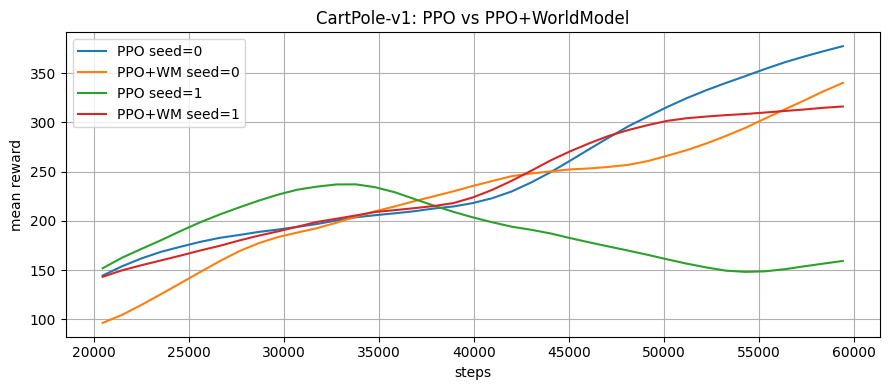

In [8]:
task2_runs = {}
task2_agents = {}
for seed in [0, 1]:
    ag, xs, ys = train_ppo('CartPole-v1', seed=seed, total_timesteps=60000,
                            continuous=False, use_wm=False,
                            num_envs=8, num_steps=128, lr=2.5e-3,
                            ent_coef=0.01)
    task2_runs[f'PPO seed={seed}'] = (xs, ys)
    task2_agents[f'PPO_{seed}'] = ag
    ag, xs, ys = train_ppo('CartPole-v1', seed=seed, total_timesteps=60000,
                            continuous=False, use_wm=True,
                            num_envs=8, num_steps=128, lr=2.5e-3,
                            ent_coef=0.01,
                            wm_updates=8, imagination_steps=10,
                            imagination_batch=40, img_iters=2, warmup=3)
    task2_runs[f'PPO+WM seed={seed}'] = (xs, ys)
    task2_agents[f'WM_{seed}'] = ag

plot_runs(task2_runs, 'CartPole-v1: PPO vs PPO+WorldModel')

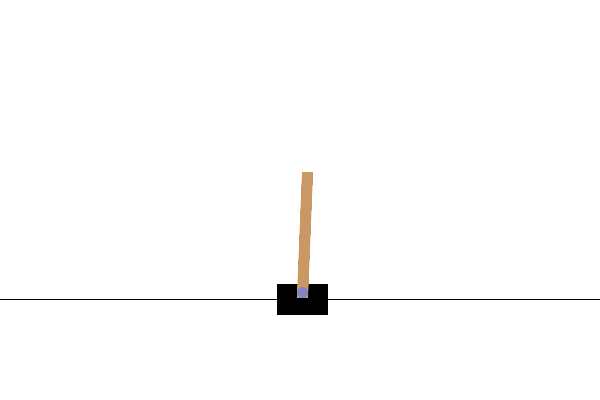

In [9]:
agent = task2_agents['WM_0']
env = gym.make('CartPole-v1', render_mode='rgb_array')
def policy(obs):
    with torch.no_grad():
        a, _, _, _ = agent.get_action_and_value(torch.Tensor(obs).to(device).unsqueeze(0))
    return int(a.cpu().numpy()[0])
record_gif(env, policy, 'cartpole.gif', duration=500, fps=30)
display(Image('cartpole.gif'))

## Задание 3. PPO vs PPO + World Model (Pendulum-v1, непрерывные действия)

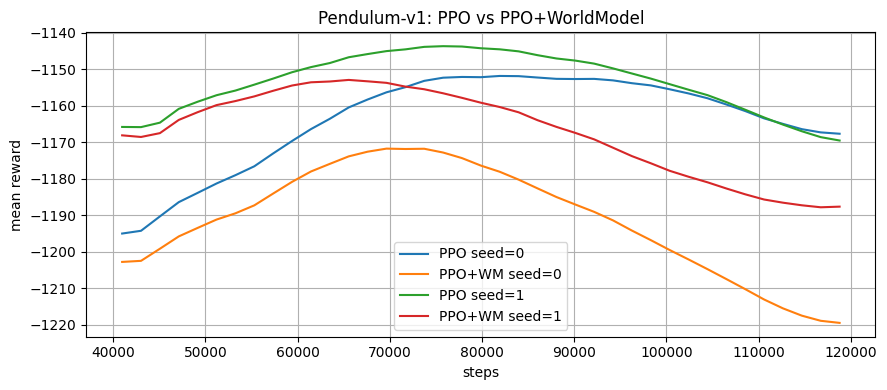

In [10]:
task3_runs = {}
task3_agents = {}
for seed in [0, 1]:
    ag, xs, ys = train_ppo('Pendulum-v1', seed=seed, total_timesteps=120000,
                            continuous=True, use_wm=False,
                            num_envs=8, num_steps=256, lr=3e-4,
                            ent_coef=0.0, max_grad_norm=0.5)
    task3_runs[f'PPO seed={seed}'] = (xs, ys)
    task3_agents[f'PPO_{seed}'] = ag
    ag, xs, ys = train_ppo('Pendulum-v1', seed=seed, total_timesteps=120000,
                            continuous=True, use_wm=True,
                            num_envs=8, num_steps=256, lr=3e-4,
                            ent_coef=0.0, max_grad_norm=0.5,
                            wm_updates=8, imagination_steps=15,
                            imagination_batch=40, img_iters=2, warmup=3)
    task3_runs[f'PPO+WM seed={seed}'] = (xs, ys)
    task3_agents[f'WM_{seed}'] = ag

plot_runs(task3_runs, 'Pendulum-v1: PPO vs PPO+WorldModel')

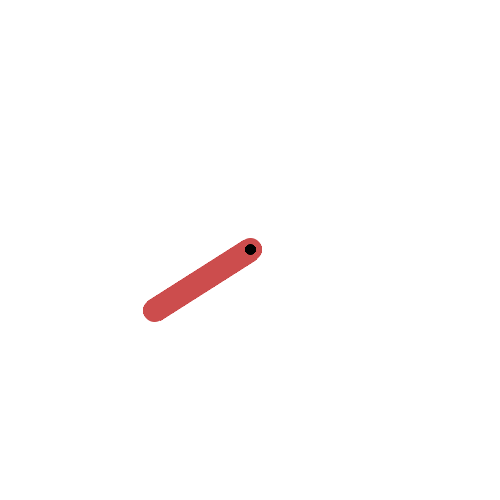

In [11]:
agent = task3_agents['WM_0']
env = gym.make('Pendulum-v1', render_mode='rgb_array')
low, high = env.action_space.low, env.action_space.high
def policy(obs):
    with torch.no_grad():
        a, _, _, _ = agent.get_action_and_value(torch.Tensor(obs).to(device).unsqueeze(0))
    return np.clip(a.cpu().numpy()[0], low, high)
record_gif(env, policy, 'pendulum.gif', duration=300, fps=30)
display(Image('pendulum.gif'))